In [230]:
import pandas as pd
import numpy
import requests
import json
from pyjstat import pyjstat


with open("utdanningsnivå.json", "r") as file:
    ssbquery_data = json.load(file)

print(ssbquery_data)
postURL = ssbquery_data["postUrl"]
ssbqury = ssbquery_data["queryObj"]
response = requests.post(postURL, json=ssbqury)
response.status_code

{'queryObj': {'query': [{'code': 'MaaleMetode', 'selection': {'filter': 'item', 'values': ['02', '10']}}, {'code': 'UtdNivaa', 'selection': {'filter': 'item', 'values': ['TOT', '3', '4']}}, {'code': 'Fagfelt', 'selection': {'filter': 'vs:Fagfelt31a', 'values': []}}, {'code': 'ContentsCode', 'selection': {'filter': 'item', 'values': ['Manedslonn']}}], 'response': {'format': 'json-stat2'}}, 'tableIdForQuery': '12407', 'postUrl': 'https://data.ssb.no/api/v0/no/table/12407'}


200

In [231]:
dataset = pyjstat.Dataset.read(response.text)
df = dataset.write("dataframe")
df_id = dataset.write("dataframe", naming="id")

df2 = df.copy()

In [232]:
df=df2.copy()
df["år"] = pd.PeriodIndex(df["år"], freq="Y")
df = df.pivot(index=["statistikkmål", "år"], columns=["utdanningsnivå"], values="value")
df["Høyere utdanning"] = df["Universitets- og høgskoleutdanning, 1-4 år (nivå 6)"]+df["Universitets- og høgskoleutdanning, over 4 år (nivå 7-8)"]
df=df.drop(columns=["Universitets- og høgskoleutdanning, 1-4 år (nivå 6)", "Universitets- og høgskoleutdanning, over 4 år (nivå 7-8)"])
df = df.astype({"Høyere utdanning": "float64"})
snitt = df.loc["Gjennomsnitt", "Høyere utdanning"]/2
sum = df.loc["Antall arbeidsforhold med lønn", "Høyere utdanning"]
ny = pd.concat([sum, snitt])
ny.index = df.index
df["Høyere utdanning"] = ny

In [233]:
df

utdanningsnivå                       Utdanningsnivå i alt  Høyere utdanning
statistikkmål                  år                                          
Antall arbeidsforhold med lønn 2015               2613125          996912.0
                               2016               2705298         1039177.0
                               2017               2756595         1068854.0
                               2018               2817311         1103435.0
                               2019               2859034         1148116.0
                               2020               2808827         1168361.0
                               2021               2938173         1224604.0
                               2022               3014011         1262234.0
                               2023               3044125         1250191.0
Gjennomsnitt                   2015                 42580           52335.0
                               2016                 43640           53245.0
                               2017                 44660           54355.0
                               2018                 46010           55940.0
                               2019                 47720           57630.0
                               2020                 48750           58260.0
                               2021                 50790           60815.0
                               2022                 53150           63415.0
                               2023                 56360           67725.0

In [234]:
import scipy.stats as spstat
snitt = df.loc["Gjennomsnitt", "Utdanningsnivå i alt"].mean()

res = spstat.ttest_1samp(df.loc["Gjennomsnitt", "Høyere utdanning"], snitt, alternative="greater")
res.pvalue
#res = spstat.ttest_ind(df.loc["Gjennomsnitt", "Høyere utdanning"],
#                 df.loc["Gjennomsnitt", "Utdanningsnivå i alt"],
#                 alternative='greater')


#Snittlønnen snittlønnen har veldig liten varians

0.00017178248775846596

In [235]:
dir(dataset)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'get_dimension_index',
 'get_dimension_indices',
 'get_value',
 'get_value_by_index',
 'get_value_index',
 'items',
 'keys',
 'move_to_end',
 'pop',
 'popitem',
 'read',
 'setdefault',
 'update',
 'values',
 'write']

In [236]:
with open("data2.json", "r") as file:
    ssbquery_data = json.load(file)

print(ssbquery_data)
postURL = ssbquery_data["postUrl"]
ssbqury = ssbquery_data["queryObj"]
response = requests.post(postURL, json=ssbqury)
response.status_code

{'queryObj': {'query': [{'code': 'MaaleMetode', 'selection': {'filter': 'item', 'values': ['02', '10']}}, {'code': 'UtdNivaa', 'selection': {'filter': 'item', 'values': ['TOT', '3', '4']}}, {'code': 'Fagfelt', 'selection': {'filter': 'vs:Fagfelt33a', 'values': ['422', '532']}}, {'code': 'ContentsCode', 'selection': {'filter': 'item', 'values': ['Manedslonn']}}], 'response': {'format': 'json-stat2'}}, 'tableIdForQuery': '12407', 'postUrl': 'https://data.ssb.no/api/v0/no/table/12407'}


200

In [237]:
dataset = pyjstat.Dataset.read(response.text)
df = dataset.write("dataframe")
df_id = dataset.write("dataframe", naming="id")

df2 = df.copy()

In [238]:
df = df2.copy()
df = df.drop(columns="statistikkvariabel")

df["år"] = pd.PeriodIndex(df["år"], freq="Y")
df = df.pivot(index=["utdanningsnivå", "år"], columns=["statistikkmål", "fagfelt"], values="value")
df.dropna(axis=0)

statistikkmål                                            Gjennomsnitt  \
fagfelt                                                 Markedsføring   
utdanningsnivå                                     år                   
Universitets- og høgskoleutdanning, over 4 år (... 2015       56170.0   
                                                   2016       57820.0   
                                                   2017       59910.0   
                                                   2018       61310.0   
                                                   2019       59940.0   
                                                   2020       61810.0   
                                                   2021       63600.0   
                                                   2022       66220.0   
                                                   2023       71060.0   
Utdanningsnivå i alt                               2015       48890.0   
                                                   2016       50000.0   
                                                   2017       51330.0   
                                                   2018       52730.0   
                                                   2019       54370.0   
                                                   2020       55500.0   
                                                   2021       58230.0   
                                                   2022       61130.0   
                                                   2023       64460.0   

statistikkmål                                                       \
fagfelt                                                 Statistikk   
utdanningsnivå                                     år                
Universitets- og høgskoleutdanning, over 4 år (... 2015    75010.0   
                                                   2016    75800.0   
                                                   2017    77410.0   
                                                   2018    78550.0   
                                                   2019    80840.0   
                                                   2020    81610.0   
                                                   2021    84930.0   
                                                   2022    89900.0   
                                                   2023    95020.0   
Utdanningsnivå i alt                               2015    72980.0   
                                                   2016    74870.0   
                                                   2017    75630.0   
                                                   2018    76930.0   
                                                   2019    77410.0   
                                                   2020    78000.0   
                                                   2021    81360.0   
                                                   2022    85270.0   
                                                   2023    89200.0   

statistikkmål                                           Antall arbeidsforhold med lønn  \
fagfelt                                                                  Markedsføring   
utdanningsnivå                                     år                                    
Universitets- og høgskoleutdanning, over 4 år (... 2015                          576.0   
                                                   2016                          584.0   
                                                   2017                          625.0   
                                                   2018                          675.0   
                                                   2019                          883.0   
                                                   2020                          924.0   
                                                   2021                         1050.0   
                                                   2022                         1132.0   
     

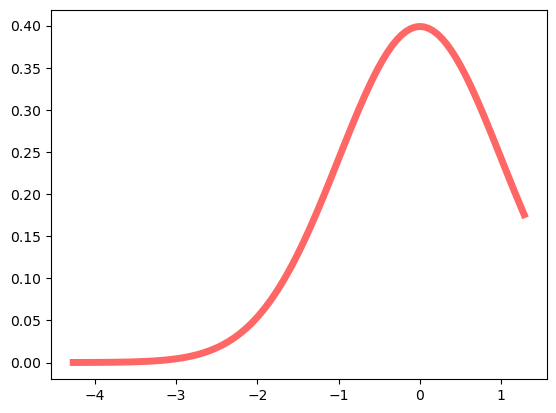

In [239]:
import numpy as np

from scipy.stats import norm

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1)

x = np.linspace(norm.ppf(0.00001),

                norm.ppf(0.9), 100)

ax.plot(x, norm.pdf(x),

       'r-', lw=5, alpha=0.6, label='norm pdf')

In [240]:
with open("annet-vinningsbrudd.json", "r") as file:
    ssbquery_data = json.load(file)

print(ssbquery_data)
postURL = ssbquery_data["postUrl"]
ssbqury = ssbquery_data["queryObj"]
response = requests.post(postURL, json=ssbqury)
response.status_code

{'queryObj': {'query': [{'code': 'LovbruddKrim', 'selection': {'filter': 'vs:LovGruppeKrimAO', 'values': ['2AAAAA-2ZZZZz']}}, {'code': 'Kjonn', 'selection': {'filter': 'item', 'values': ['2', '1']}}, {'code': 'ContentsCode', 'selection': {'filter': 'item', 'values': ['Personoffer']}}], 'response': {'format': 'json-stat2'}}, 'tableIdForQuery': '08635', 'postUrl': 'https://data.ssb.no/api/v0/no/table/08635'}


200

In [241]:
dataset = pyjstat.Dataset.read(response.text)
df = dataset.write("dataframe")
df_id = dataset.write("dataframe", naming="id")

df2 = df.copy()

2.652449014603229 0.005797757505063613
Nullhypotese forkastes: Menn er mer sannynlig å være offer for annen vinningskriminalitet


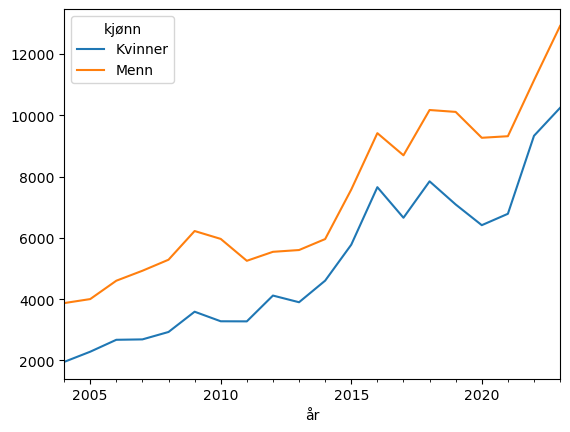

In [242]:
df = df2.copy()
df = df.drop(columns=["lovbruddstype", "statistikkvariabel"])
df["år"] = pd.PeriodIndex(df["år"], freq="Y")
df = df.pivot(index="år", columns="kjønn", values="value")
df["Totalt"] = df["Kvinner"]+df["Menn"]
df[["Kvinner", "Menn"]].plot()

t, p = spstat.ttest_ind(df["Menn"], df["Kvinner"], alternative="greater")
print(t, p)
alpha = 0.05

if p<alpha:
    print("Nullhypotese forkastes: Menn er mer sannynlig å være offer for annen vinningskriminalitet")
else:
    print("Nullhypotese beholdes: Menn er ikke mer sannsynlig å være offer for annen vinningskriminalitet")

In [243]:
d2016 = df.loc["2023"]
p_menn = d2016["Menn"]/d2016["Totalt"]
n = d2016["Totalt"]

res = spstat.binomtest(d2016["Menn"], n, p=0.5, alternative="greater")

print(f"p-verdi = {res.pvalue}")
df["diff"] = df["Menn"]-df["Kvinner"]
df.sort_values("diff")
n_menn = df.loc["2014", "Menn"]
n = df.loc["2014", "Totalt"]

p-verdi = 2.0142194919628677e-69


In [244]:

df

kjønn,Kvinner,Menn,Totalt,diff
år,,,,
2004,1953,3872,5825,1919
2005,2286,4003,6289,1717
2006,2675,4602,7277,1927
2007,2688,4927,7615,2239
2008,2930,5287,8217,2357
2009,3591,6223,9814,2632
2010,3279,5966,9245,2687
2011,3276,5252,8528,1976
2012,4118,5545,9663,1427


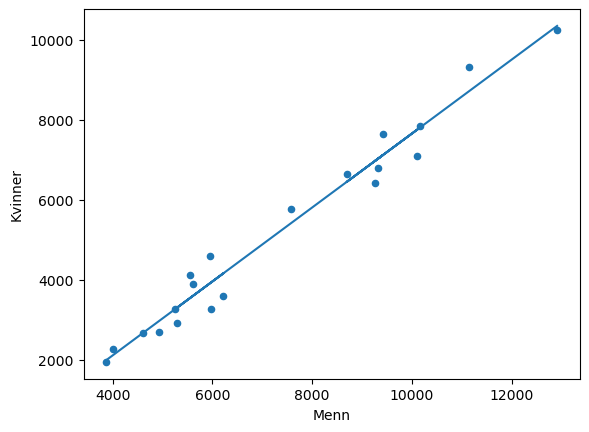

In [245]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

ax = df.plot.scatter(x="Menn", y="Kvinner")

model = LinearRegression()
model.fit(df[["Menn"]], df["Kvinner"])

df["Modell"] = model.predict(df[["Menn"]])
plt.plot(df["Menn"], df["Modell"])

#Gir det mening? Nei

In [246]:
import statsmodels.stats.proportion as smp

# Parameters
n = float(df.loc["2023", "Totalt"])# total number of trials
k = float(df.loc["2023", "Menn"])  # observed number of successes
confidence_level = 0.95  # 95% confidence interval

# Calculate the confidence interval for p
ci_low, ci_high = smp.proportion_confint(count=k, nobs=n, alpha=1-confidence_level, method='wilson')
print(f"Estimated p: {k/n}")
print(f"{confidence_level*100}% Confidence Interval: ({ci_low}, {ci_high})")

Estimated p: 0.5576956296424253
95.0% Confidence Interval: (0.551289594915686, 0.5640825247402685)
